In [5]:
import pandas as pd
import glob
import os

# Tìm tất cả file google_maps_reviews*.csv
files = glob.glob("google_maps_reviews*.csv")

all_data = []

for file_path in files:
    try:
        df = pd.read_csv(file_path)

        # Xóa dòng có text rỗng / null
        df = df.dropna(subset=["text"])
        df = df[df["text"].astype(str).str.strip() != ""]

        # Thêm tên file
        df["source_file"] = os.path.basename(file_path)

        print(f"✅ {file_path}: {len(df)} reviews hợp lệ")

        all_data.append(df)

    except Exception as e:
        print(f"❌ Lỗi {file_path}: {e}")

# Gộp tất cả dữ liệu
merged_df = pd.concat(all_data, ignore_index=True)

print("\n===== SAU KHI LỌC =====")
print(merged_df.head())

print(f"\nTổng số review hợp lệ: {len(merged_df)}")

# Lưu file mới
merged_df.to_csv("clean_google_maps_reviews.csv", index=False)

print("\n💾 Đã lưu: clean_google_maps_reviews.csv")

✅ google_maps_reviews_20260516_081554.csv: 43 reviews hợp lệ
✅ google_maps_reviews_20260516_091112.csv: 4869 reviews hợp lệ
✅ google_maps_reviews_20260516_102712.csv: 5240 reviews hợp lệ
✅ google_maps_reviews_20260517_123411.csv: 557 reviews hợp lệ
✅ google_maps_reviews_20260517_131018.csv: 6706 reviews hợp lệ
✅ google_maps_reviews_20260517_153159.csv: 3 reviews hợp lệ

===== SAU KHI LỌC =====
                       place_name          user rating time  \
0  Buffet Gánh Khách Sạn Bông Sen     Chau Minh    NaN  NaN   
1  Buffet Gánh Khách Sạn Bông Sen        Duc Du    NaN  NaN   
2  Buffet Gánh Khách Sạn Bông Sen    Kim Yên JP    NaN  NaN   
3  Buffet Gánh Khách Sạn Bông Sen    Anh Nguyễn    NaN  NaN   
4  Buffet Gánh Khách Sạn Bông Sen  Yamamoto Bui    NaN  NaN   

                                                text  \
0  Mới ăn trưa tại đây, thật sự không hấp dẫn , m...   
1  Chất lượng món ăn buffet Gánh không đảm bảo. T...   
2  Lần trước mình ở ks thây ok, lần này tiếp tục ...   


In [6]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("clean_google_maps_reviews.csv")

# Tính số lượng từ trong mỗi review
df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

# Lọc review ngắn theo số từ
# Ví dụ: dưới 5 từ
short_reviews = df[df["word_count"] < 2]

# Tổng số review ngắn
print(f"Tổng số review ngắn (<5 từ): {len(short_reviews)}")

# Thống kê phân phối word count
print("\n===== PHÂN PHỐI WORD COUNT =====")
print(df["word_count"].describe())

# Hiển thị ví dụ
print("\n===== REVIEW NGẮN =====")
print(short_reviews[["text", "word_count"]].head(20))

Tổng số review ngắn (<5 từ): 50

===== PHÂN PHỐI WORD COUNT =====
count    17418.000000
mean        28.735676
std         28.242289
min          1.000000
25%         10.000000
50%         22.000000
75%         42.000000
max        744.000000
Name: word_count, dtype: float64

===== REVIEW NGẮN =====
          text  word_count
49      3,5/10           1
351    Ngon!!!           1
817     Ngonnn           1
861    ngônnnn           1
921      Tuyệt           1
923      Tuyệt           1
1040     Tuyệt           1
1840     Tuyệt           1
2738    Thoáng           1
2823     Tuyệt           1
2880   ngonnnn           1
2892     Đẹp!!           1
2909     Được           1
2979     tuyet           1
3798     Ngon!           1
4021     Tốt..           1
4145     Ngoan           1
4152  Ngonnnnn           1
4290     Ngon.           1
4512    Thường           1


In [7]:
import pandas as pd
import re

# Đọc dữ liệu
df = pd.read_csv("clean_google_maps_reviews.csv")

# =========================
# CLEAN RATING
# =========================
# Ví dụ:
# "1 sao" -> 1
# "5 stars" -> 5

df["rating"] = (
    df["rating"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

# bỏ rating lỗi/null
df = df.dropna(subset=["rating"])

# =========================
# TEXT PREPROCESSING
# =========================
def preprocess_text(text):
    text = str(text)

    # lowercase
    text = text.lower()

    # bỏ url
    text = re.sub(r"http\S+|www\S+", "", text)

    # bỏ ký tự đặc biệt
    text = re.sub(r"[^\w\s]", " ", text)

    # bỏ số
    text = re.sub(r"\d+", "", text)

    # bỏ khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()

    return text

# preprocess
df["clean_text"] = df["text"].apply(preprocess_text)

# =========================
# WORD COUNT
# =========================
df["word_count"] = df["clean_text"].apply(
    lambda x: len(x.split())
)

# =========================
# FILTER
# =========================
MIN_WORDS = 5
MAX_WORDS = 50

filtered_df = df[
    (df["word_count"] >= MIN_WORDS) &
    (df["word_count"] <= MAX_WORDS)
]

# =========================
# SORT RATING
# =========================
filtered_df = filtered_df.sort_values(
    by="rating",
    ascending=True
)

print(f"Tổng review ban đầu: {len(df)}")
print(f"Sau filtering: {len(filtered_df)}")

# =========================
# CHECK DISTRIBUTION
# =========================
print("\n===== RATING DISTRIBUTION =====")
print(filtered_df["rating"].value_counts().sort_index())

# =========================
# SAMPLE
# =========================
print("\n===== SAMPLE =====")

print(
    filtered_df[
        ["rating", "text", "clean_text", "word_count"]
    ].head(20)
)

# =========================
# SAVE
# =========================
filtered_df.to_csv(
    "preprocessed_filtered_reviews_sorted.csv",
    index=False
)

print("\n✅ Đã lưu: preprocessed_filtered_reviews_sorted.csv")

Tổng review ban đầu: 17361
Sau filtering: 12579

===== RATING DISTRIBUTION =====
rating
1.0    6171
2.0     850
3.0    1358
4.0    2120
5.0    2080
Name: count, dtype: int64

===== SAMPLE =====
      rating                                               text  \
8595     1.0  Xôi cua! Thật sự là một phần nhỏ nhưng rất ngo...   
5769     1.0             Tệ nhân viên thái độ đồ ăn bình thường   
5768     1.0      Nhân viên bất lịch sự\nChén mẻ\nĐồ ăn ko ngon   
5767     1.0   Phục vụ chậm, lơ là. Thái độ nhân viên khó chịu.   
5766     1.0                 Quán ăn ngon, rộng rãi thoáng mát.   
5765     1.0           Nv quán quá kinh khủng, không có lần sau   
5764     1.0          Phải gọi là quán ăn chứ ko phải nhà hàng,   
5763     1.0         Dịch vụ kém khiến trải nghiệm ăn uống tệ !   
5762     1.0  Nhân viên lườm khách, cãi lại khách, thái độ k...   
5761     1.0  Thái độ nhân viên ko tốt, trả lời khách bất lị...   
5770     1.0                      Tự xem lại nhân viên của mình   
57

===== STAR DISTRIBUTION =====
rating
1.0    6171
2.0     850
3.0    1358
4.0    2120
5.0    2080
Name: count, dtype: int64


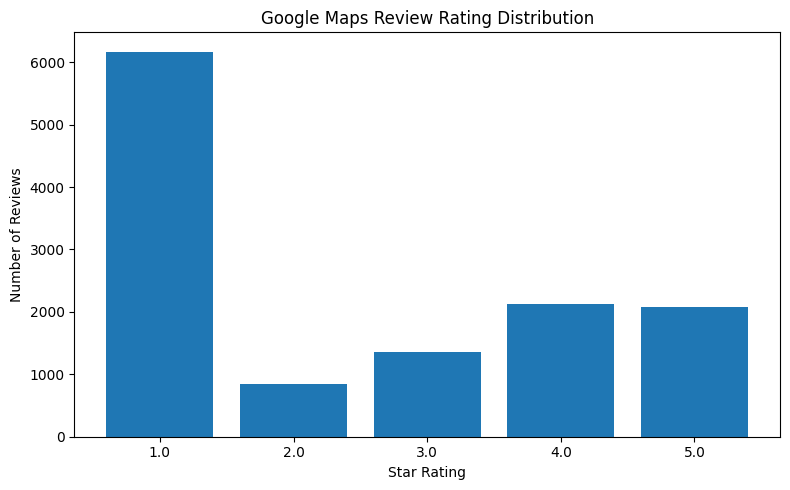


===== PERCENTAGE =====
rating
1.0    49.06
2.0     6.76
3.0    10.80
4.0    16.85
5.0    16.54
Name: count, dtype: float64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("preprocessed_filtered_reviews_sorted.csv")

# =========================
# PHÂN BỐ SỐ SAO
# =========================
star_counts = df["rating"].value_counts().sort_index()

print("===== STAR DISTRIBUTION =====")
print(star_counts)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))

plt.bar(
    star_counts.index.astype(str),
    star_counts.values
)

plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Google Maps Review Rating Distribution")

plt.tight_layout()
plt.show()

# =========================
# PHẦN TRĂM
# =========================
print("\n===== PERCENTAGE =====")

percentages = (
    star_counts / len(df) * 100
).round(2)

print(percentages)

In [9]:
# 1. Count duplicates based ONLY on the text column
text_duplicate_count = df.duplicated(subset=['text']).sum()
print(f"Number of duplicate review texts: {text_duplicate_count}")

# 2. View all rows that share a duplicate text (including the first occurrence)
# We sort by 'review_text' so identical reviews appear next to each other
text_duplicates = df[df.duplicated(subset=['text'], keep=False)].sort_values(by='text')

print("--- Rows with Duplicate Review Text ---")
print(text_duplicates[['text']].head(20)) # Adjust columns as needed

Number of duplicate review texts: 56
--- Rows with Duplicate Review Text ---
                                                    text
11224  #Tự hào người Việt Nam\n#Quốc Khánh 2/9\n#Busa...
11228  #Tự hào người Việt Nam\n#Quốc Khánh 2/9\n#Busa...
11220  #Tự hào người Việt Nam\n#Quốc Khánh 2/9\n#Busa...
11219  #Tự hào người Việt Nam\n#Quốc Khánh 2/9\n#Busa...
4787                               Bánh mì kẹp thịt ngon
7227                               Bánh mì kẹp thịt ngon
4076                                   Chờ đồ ăn quá lâu
5821                                   Chờ đồ ăn quá lâu
11913                            Cơm gà ngon nhất Hội An
8618                             Cơm gà ngon nhất Hội An
11792                            Cơm ngon, giá cả hợp lý
11649                            Cơm ngon, giá cả hợp lý
8791                               Cơm ngon, giá hơi cao
7149                               Cơm ngon, giá hơi cao
12574                               Cơm ngon, giá hợp lý
7316       

In [10]:
import pandas as pd

df = pd.read_csv("preprocessed_filtered_reviews_sorted.csv")

test = "Trái cây cắt để lên mặt bàn bàn như này thì có"

result = df[df["text"].str.contains(test, na=False, regex=False)]

print(df.shape)
print(result.index)

(12579, 8)
Index([], dtype='int64')


In [11]:
df = pd.read_csv("..\output_labeled\google_maps_reviews_labeled_20260514_191809.csv")
df.info()
df.tail(1)

FileNotFoundError: [Errno 2] No such file or directory: '..\\output_labeled\\google_maps_reviews_labeled_20260514_191809.csv'